<a href="https://colab.research.google.com/github/uditnarayanpandey/Machine_Learning_Practice/blob/Master/Deep%20Learning/src/Concepts/Hyperparameter_Tuning/ANN_hyperparameter_tuning_using_optuna_in_pytorch.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Fashion-MNIST Multiclass Clasification Using **ANN** In **Pytorch**

---
This notebook demonstrates the PyTorch implementation of an **Artificial Neural Network (ANN)** applied to the Fashion MNIST dataset. The dataset consists of images represented by **784** features and a single label indicating the product category. Additionally, this notebook showcases the use of **OPTUNA** for hyperparameter optimization to identify the best parameters for our neural network.

## **1. Installing Necessary Modules/Packages**
---
In this section, we focus on installing all the required modules and packages that are essential for building, training, and optimizing our neural network. These installations ensure that the environment is equipped with the tools needed for data manipulation, model implementation, hyperparameter tuning, and result visualization.

In [ ]:
# Installing OPTUNA
!pip install optuna

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 364.4/364.4 kB 6.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 233.5/233.5 kB 10.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 78.6/78.6 kB 4.5 MB/s eta 0:00:00


## **2. Importing Lirbraries**
---
In this section, we are importing all the necessary libraries that are essential for various tasks, including the preprocessing and manipulation of the dataset, implementing the neural network, and visualizing graphs and plots to gain insights into the data and the model's performance.

In [ ]:
# Standard library imports
import os
import zipfile

# Libraries for data manipulation
import pandas as pd
import numpy as np

# Libraries for data preprocessing and model evaluation
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler

# PyTorch libraries for model implementation
import torch
from torch import nn
from torch.utils.data import Dataset, DataLoader
import torch.optim as optim

# Libraries for data visualization
import matplotlib.pyplot as plt

# Libraries for interacting with Google Drive
from google.colab import files
from google.colab import drive

In [ ]:
# Setting up the seed value for reproducability
torch.manual_seed(42)

## **3. Configuring The Available Device**
---
In this section, we check the availability of a GPU in the current environment and configure the device accordingly. If a GPU is available, we set it as the primary device to leverage its computational power for faster training and optimization of the neural network. If not, the CPU is selected as the fallback device. This ensures that our code runs seamlessly regardless of the hardware configuration.

In [ ]:
# Check for GPU
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"Using device: {device}")

Using device: cpu


## **4. Config Variables**
---
This section enhances code maintainability by consolidating all configurable settings in a single, easily accessible location. By defining and initializing all configuration variables here, the code becomes more flexible and adaptable, as modifications to these settings can be made without altering the core logic of the program.

In [ ]:
FILE_PATH= '/content/'
DATASET_PATH= '/content/Dataset/'
KAGGLE_KEY_PATH= '/content/drive/MyDrive/Kaggle/kaggle.json'
KAGGLE_DATASET_PATH= 'zalando-research/fashionmnist'

In [ ]:
# mapping the categories with the label code
labels_map = {
    0: "T-Shirt",
    1: "Trouser",
    2: "Pullover",
    3: "Dress",
    4: "Coat",
    5: "Sandal",
    6: "Shirt",
    7: "Sneaker",
    8: "Bag",
    9: "Ankle Boot",
}

## **5. User Defined Functions**
---
In this section, we define custom functions that will be used throughout the notebook to streamline various processes. These functions are tailored to perform specific tasks such as data preprocessing, model training, evaluation, and visualization, helping to make the code more modular, reusable, and easier to understand.

In [ ]:
def download_dataset_from_kaggle(kaggle_key_path:str, kaggle_dataset_path:str):
    """use to download a dataset from kaggle
    input[str]: kaggle_key_input -> API key to connect with Kaggle
                kaggle_dataset_path -> path to download the dataset
    output[None]: Dataset downloaded in the form of a CSV
    """
    # Step 1 : Mount Google Drive
    drive.mount('/content/drive')

    if os.path.isdir('/content/drive/MyDrive'):
        !mkdir ~/.kaggle
        !cp {kaggle_key_path} ~/.kaggle/
        !chmod 600 ~/.kaggle/kaggle.json
    else:
        print("Please upload the Kaggle.json file from your local machine!!", "\n")
        files.upload()
        !mkdir ~/.kaggle
        !cp kaggle.json ~/.kaggle/
        !chmod 600 ~/.kaggle/kaggle.json

    # Step 2: Create the 'Dataset' folder if it doesn't exist
    dataset_folder = '/content/Dataset'
    if not os.path.exists(dataset_folder):
        os.makedirs(dataset_folder)

    # Step 3: Download the dataset from Kaggle into the 'Dataset' folder
    !kaggle datasets download -d {kaggle_dataset_path} -p {dataset_folder}

    # Step 4: Unzip the downloaded dataset into the 'Dataset' folder
    # Find the downloaded zip file
    try:
        for file in os.listdir(dataset_folder):
            if file.endswith(".zip"):
                zip_path = os.path.join(dataset_folder, file)
                with zipfile.ZipFile(zip_path, 'r') as zip_ref:
                    zip_ref.extractall(dataset_folder)  # Unzip within the Dataset folder
                os.remove(zip_path)  # Optionally, delete the zip file after extraction
    except FileNotFoundError as e:
        print(f"File not present at the destination. Error occured -> {e}")
    else:
        print("Dataset downloaded and unzipped in the Dataset folder.")
        drive.flush_and_unmount()


## **6. Downloading The Dataset**
---
In this section, we focus on downloading the Fashion MNIST dataset, which will be used for training and evaluating the neural network. The dataset is either retrieved from an online source or loaded from local storage, depending on the setup. This step ensures that the data is readily available for preprocessing and analysis.

In [ ]:
download_dataset_from_kaggle(kaggle_key_path= KAGGLE_KEY_PATH, kaggle_dataset_path=KAGGLE_DATASET_PATH)

Mounted at /content/drive
Dataset URL: https://www.kaggle.com/datasets/zalando-research/fashionmnist
License(s): other
 97% 67.0M/68.8M [00:03<00:00, 25.8MB/s]
100% 68.8M/68.8M [00:03<00:00, 23.3MB/s]
Dataset downloaded and unzipped in the Dataset folder.


## **7. Loading the Dataset**
---
Below given link is a subset of the main Dataset with only 6000 rows. If you want to test the implementation, you can utilize it.
> **Dataset Link** : https://drive.google.com/file/d/1ziN7gJHnr-MQb0_eFsPfPfiiDuvsmqVH/view

In [ ]:
# Loading the dataset
train_df = pd.read_csv('/content/Dataset/fashion-mnist_train.csv')
test_df = pd.read_csv('/content/Dataset/fashion-mnist_test.csv')

In [ ]:
# Train Dataset
train_df.head()

,label,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,...,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783,pixel784
0,2,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,9,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,6,0,0,0,0,0,0,0,5,0,...,0,0,0,30,43,0,0,0,0,0
3,0,0,0,0,1,2,0,0,0,0,...,3,0,0,0,0,1,0,0,0,0
4,3,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [ ]:
# Test Dataset
test_df.head()

,label,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,...,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783,pixel784
0,0,0,0,0,0,0,0,0,9,8,...,103,87,56,0,0,0,0,0,0,0
1,1,0,0,0,0,0,0,0,0,0,...,34,0,0,0,0,0,0,0,0,0
2,2,0,0,0,0,0,0,14,53,99,...,0,0,0,0,63,53,31,0,0,0
3,2,0,0,0,0,0,0,0,0,0,...,137,126,140,0,133,224,222,56,0,0
4,3,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


## **8. EDA (Exploratory Data Analysis)**
---
In this section we explore the Dataset to find the necessary information around the data.

In [ ]:
train_df.shape

(60000, 785)

In [ ]:
test_df.shape

(10000, 785)

## **9. Visualising the Dataset**
---
In this section we're picking random data and mapping it with the labels defined above in the config variable section to visualize the data for the sample inputs

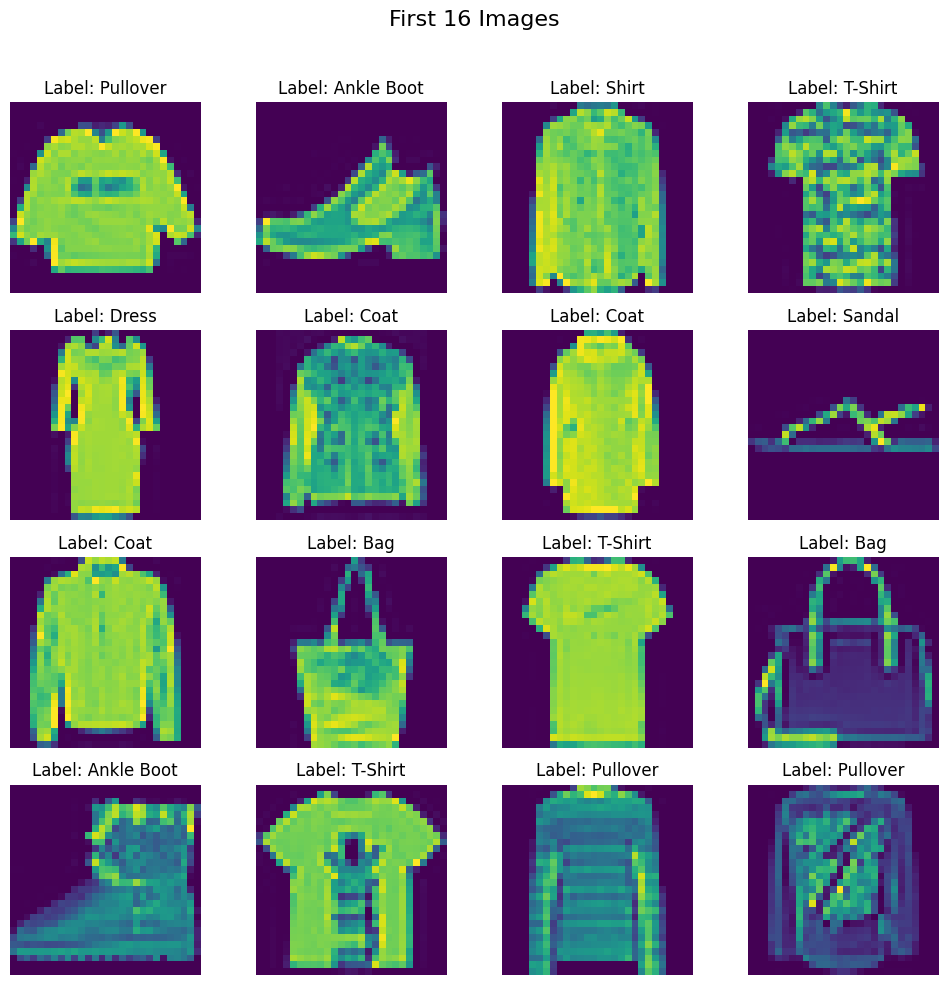

In [ ]:
# Create a 4x4 grid of images
fig, axes = plt.subplots(4, 4, figsize=(10, 10))
fig.suptitle("First 16 Images", fontsize=16)

# Plot the first 16 images from the dataset
for i, ax in enumerate(axes.flat):
    img = train_df.iloc[i, 1:].values.reshape(28, 28)  # Reshape to 28x28
    ax.imshow(img)  # Display in grayscale
    ax.axis('off')  # Remove axis for a cleaner look
    ax.set_title(f"Label: {labels_map[train_df.iloc[i, 0]]}")  # Show the label

plt.tight_layout(rect=[0, 0, 1, 0.96])  # Adjust layout to fit the title
plt.show()


## **10. Train - Validation split**
---
In this section, we split the dataset into two subsets: training and validation. The training set is used to train the neural network, while the validation set is used to evaluate the model's performance during training. This separation helps in monitoring the model's generalization ability and tuning hyperparameters effectively.

In [ ]:
# Separating data features, labels to X, y
X = train_df.iloc[:, 1:].values
y = train_df.iloc[:, 0].values

In [ ]:
# Splitting the data into train, validation with validation having 20% of the data
X_train, X_validation, y_train, y_validation = train_test_split(X, y, test_size=0.2, random_state=42)

## **11. Scaling the Dataset**
---
Since, our features are at different scale as we can see there's sparsity in the dataset with majority of the feature being 0. It is important for us to scale the feature for faster gradient calculation

We'll use **MinMax** scaler as the maximum pixel value is known to us. Which is **255**

In [ ]:
# Inititalize the min-max scaler
scaler = MinMaxScaler()

In [ ]:
# Scaling X_train, X_validation
X_train_scaled = scaler.fit_transform(X_train)
X_validation_scaled = scaler.transform(X_validation)

## **12. Creating a Custom Dataset Class**
---
**Dataset class** would allows us to efficiently handle, preprocess, and manage your data for training and testing machine learning models

In [ ]:
class CustomDataset(Dataset):
    def __init__(self, features, labels):
        # converting the numpy array features to tensors
        self.features = torch.tensor(features, dtype=torch.float32)
        self.labels = torch.tensor(labels, dtype=torch.long)

    def __len__(self):
        return len(self.features)

    def __getitem__(self, index):
        return self.features[index], self.labels[index]

In [ ]:
# Create train_dataset object
train_dataset = CustomDataset(X_train_scaled, y_train)

# Create validation_dataset object
validation_dataset = CustomDataset(X_validation_scaled, y_validation)

In [ ]:
train_dataset[0]

(tensor([0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.2275,
         0.5333, 0.0000, 0.0

## **13. Build Neural Architecture**
---
Here in this section of the notebook, we're going to build a basic Neural Network (ANN)

In [ ]:
class FashionANN(nn.Module):
    def __init__(self, num_input_features, output_dim, num_hidden_layers, neurons_per_layer, dropout_rate):
        super().__init__()

        # Empty dict to create the architecture
        layers= []

        for i in range(num_hidden_layers):
            layers.append(nn.Linear(num_input_features, neurons_per_layer))
            layers.append(nn.BatchNorm1d(neurons_per_layer))
            layers.append(nn.ReLU())
            layers.append(nn.Dropout(dropout_rate))
            num_input_features = neurons_per_layer
        layers.append(nn.Linear(neurons_per_layer, output_dim))

        self.model = nn.Sequential(*layers)

    def forward(self, x):
        return self.model(x)

## **14. Early Stopping**

In [ ]:
class EarlyStopping:
    """Early stops the training if validation loss doesn't improve after a given patience."""
    def __init__(self, patience=7, verbose=False, delta=0, path='checkpoint.pt', trace_func=print):
        """
        Args:
            patience (int): How long to wait after last time validation loss improved.
                            Default: 7
            verbose (bool): If True, prints a message for each validation loss improvement.
                            Default: False
            delta (float): Minimum change in the monitored quantity to qualify as an improvement.
                            Default: 0
            path (str): Path for the checkpoint to be saved to.
                            Default: 'checkpoint.pt'
            trace_func (function): trace print function.
                            Default: print
        """
        self.patience = patience
        self.verbose = verbose
        self.counter = 0
        self.best_val_loss = None
        self.early_stop = False
        self.val_loss_min = np.inf
        self.delta = delta
        self.path = path
        self.trace_func = trace_func

    def __call__(self, val_loss, model):
        # Check if validation loss is nan
        if np.isnan(val_loss):
            self.trace_func("Validation loss is NaN. Ignoring this epoch.")
            return

        if self.best_val_loss is None:
            self.best_val_loss = val_loss
            self.save_checkpoint(val_loss, model)
        elif val_loss < self.best_val_loss - self.delta:
            # Significant improvement detected
            self.best_val_loss = val_loss
            self.save_checkpoint(val_loss, model)
            self.counter = 0  # Reset counter since improvement occurred
        else:
            # No significant improvement
            self.counter += 1
            self.trace_func(f'EarlyStopping counter: {self.counter} out of {self.patience}')
            if self.counter >= self.patience:
                self.early_stop = True

    def save_checkpoint(self, val_loss, model):
        '''Saves model when validation loss decreases.'''
        if self.verbose:
            self.trace_func(f'Validation loss decreased ({self.val_loss_min:.6f} --> {val_loss:.6f}).  Saving model ...')
        torch.save(model.state_dict(), self.path)
        self.val_loss_min = val_loss

## **15. Implementing Optuna for Hyperparameter Tuning**
---
In this section, we utilize Optuna, a powerful optimization framework, to perform hyperparameter tuning for our neural network. Optuna helps automate the search for the best combination of hyperparameters, such as learning rate, batch size, and the number of neurons in each layer, to optimize the model's performance. By systematically exploring the hyperparameter space, we aim to enhance the accuracy and efficiency of the model.

In [ ]:
# Defining an Objective function
def objective(trial):

    # Setting up the hyperparameters from the search space
    num_hidden_layers = trial.suggest_int('num_hidden_layers', 1, 5)
    neurons_per_layer = trial.suggest_int('neurons_per_layer', 8, 256, step=8)
    dropout_rate = trial.suggest_float('dropout_rate', 0.1, 0.5, step=0.1)
    epochs = trial.suggest_int('epochs', 10, 30, step=10)
    learning_rate = trial.suggest_float('learning_rate', 1e-5, 1e-1, log=True)
    batch_size = trial.suggest_categorical('batch_size', [16, 32, 64, 128])
    optimizer_name = trial.suggest_categorical("optimizer", ['Adam', 'SGD', 'RMSprop'])
    weight_decay = trial.suggest_float('weight_decay', 1e-5, 1e-3, log=True)

    train_dataloader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, pin_memory=True)
    validation_dataloader = DataLoader(validation_dataset, batch_size=batch_size, shuffle=False, pin_memory=True)

    # Initialize the model
    num_input_features = 784
    output_dim = 10
    model = FashionANN(num_input_features, output_dim, num_hidden_layers, neurons_per_layer, dropout_rate)

    # Moving model to cpu/gpu based on the availability
    model.to(device)

    # Selection of optimizer
    criterion = nn.CrossEntropyLoss()

    if optimizer_name == 'Adam':
        optimizer = optim.Adam(model.parameters(), lr=learning_rate, weight_decay=weight_decay)
    elif optimizer_name == 'SGD':
        optimizer = optim.SGD(model.parameters(), lr=learning_rate, weight_decay=weight_decay)
    else:
        optimizer = optim.RMSprop(model.parameters(), lr=learning_rate, weight_decay=weight_decay)

    loss_keeper={'train':[],'valid':[]}

    for epoch in range(epochs):
        train_loss=0.0
        valid_loss=0.0

        """
        TRAINING PHASE
        """
        model.train() # Model is in training mode
        for batch_features, batch_labels in train_dataloader:
            if device == 'cuda':
                # move data to gpu
                batch_features, batch_labels = batch_features.to(device), batch_labels.to(device)

            # forward + backward + optimize
            output = model(batch_features)
            # calculating loss
            loss = criterion(output, batch_labels)
            # zero the parameter gradients
            optimizer.zero_grad()
            # backward propagation
            loss.backward()
            optimizer.step()
            # print statistics
            train_loss+=loss.item()

        """
        VALIDATION PHASE
        """
        model.eval() # Model is in validation mode
        with torch.no_grad():
            for batch_features, batch_labels in validation_dataloader:
                if device == 'cuda':
                    # move data to gpu
                    batch_features, batch_labels = batch_features.to(device), batch_labels.to(device)

                output = model(batch_features)
                loss = criterion(output, batch_labels)
                valid_loss+=loss.item()

        avg_train_loss = train_loss/len(train_dataloader)
        avg_validation_loss = valid_loss/len(validation_dataloader)
        loss_keeper['train'].append(avg_train_loss)
        loss_keeper['valid'].append(avg_validation_loss)
        # print(f"\nEpoch : {epoch+1}\tTraining Loss : {avg_train_loss}\tValidation Loss : {avg_validation_loss}")
    return sum(loss_keeper['valid']) / len(loss_keeper['valid'])

In [ ]:
import optuna

study = optuna.create_study(direction='minimize')

[I 2025-01-16 13:33:32,275] A new study created in memory with name: no-name-6d6103e0-1604-4e1a-bdd9-12182793581f


In [ ]:
study.optimize(objective, n_trials=10)

[I 2025-01-16 13:36:05,256] Trial 0 finished with value: 0.6795940993679894 and parameters: {'num_hidden_layers': 1, 'neurons_per_layer': 168, 'dropout_rate': 0.1, 'epochs': 30, 'learning_rate': 6.939595026086314e-05, 'batch_size': 16, 'optimizer': 'SGD', 'weight_decay': 0.00015030088824236054}. Best is trial 0 with value: 0.6795940993679894.
[I 2025-01-16 13:36:35,974] Trial 1 finished with value: 0.42780478387436965 and parameters: {'num_hidden_layers': 4, 'neurons_per_layer': 80, 'dropout_rate': 0.5, 'epochs': 20, 'learning_rate': 0.00140344490014866, 'batch_size': 128, 'optimizer': 'RMSprop', 'weight_decay': 6.62494822655886e-05}. Best is trial 1 with value: 0.42780478387436965.
[I 2025-01-16 13:38:07,731] Trial 2 finished with value: 0.4442677180857419 and parameters: {'num_hidden_layers': 5, 'neurons_per_layer': 80, 'dropout_rate': 0.1, 'epochs': 30, 'learning_rate': 1.8884696856108405e-05, 'batch_size': 64, 'optimizer': 'RMSprop', 'weight_decay': 1.63715732110952e-05}. Best is t

In [ ]:
study.best_value

0.3297085660129786

In [ ]:
# objective function
def objective(trial):

  # next hyperparameter values from the search space
  num_hidden_layers = trial.suggest_int("num_hidden_layers", 1, 5)
  neurons_per_layer = trial.suggest_int("neurons_per_layer", 8, 128, step=8)
  epochs = trial.suggest_int("epochs", 10, 50, step=10)
  learning_rate = trial.suggest_float("learning_rate", 1e-5, 1e-1, log=True)
  dropout_rate = trial.suggest_float("dropout_rate", 0.1, 0.5, step=0.1)
  batch_size = trial.suggest_categorical("batch_size", [16, 32, 64, 128])
  optimizer_name = trial.suggest_categorical("optimizer", ['Adam', 'SGD', 'RMSprop'])
  weight_decay = trial.suggest_float("weight_decay", 1e-5, 1e-3, log=True)

  train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, pin_memory=True)
  test_loader = DataLoader(validation_dataset, batch_size=batch_size, shuffle=False, pin_memory=True)

  # model init
  input_dim = 784
  output_dim = 10

  model = FashionANN(input_dim, output_dim, num_hidden_layers, neurons_per_layer, dropout_rate)
  model.to(device)

  # optimizer selection
  criterion = nn.CrossEntropyLoss()
  optimizer = optim.SGD(model.parameters(), lr=0.1, weight_decay=1e-4)

  if optimizer_name == 'Adam':
    optim.Adam(model.parameters(), lr=learning_rate, weight_decay=weight_decay)
  elif optimizer_name == 'SGD':
    optim.SGD(model.parameters(), lr=learning_rate, weight_decay=weight_decay)
  else:
    optim.RMSprop(model.parameters(), lr=learning_rate, weight_decay=weight_decay)

  # training loop

  for epoch in range(epochs):

    for batch_features, batch_labels in train_loader:

      # move data to gpu
      batch_features, batch_labels = batch_features.to(device), batch_labels.to(device)

      # forward pass
      outputs = model(batch_features)

      # calculate loss
      loss = criterion(outputs, batch_labels)

      # back pass
      optimizer.zero_grad()
      loss.backward()

      # update grads
      optimizer.step()


  # evaluation
  model.eval()
  # evaluation on test data
  total = 0
  correct = 0

  with torch.no_grad():

    for batch_features, batch_labels in test_loader:

      # move data to gpu
      batch_features, batch_labels = batch_features.to(device), batch_labels.to(device)

      outputs = model(batch_features)

      _, predicted = torch.max(outputs, 1)

      total = total + batch_labels.shape[0]

      correct = correct + (predicted == batch_labels).sum().item()

    accuracy = correct/total

  return accuracy

In [ ]:
import optuna

study = optuna.create_study(direction='maximize')

[I 2025-01-16 13:50:18,520] A new study created in memory with name: no-name-7826e2c0-d5e2-4459-afda-ee95cbcbf7f2


In [ ]:
study.optimize(objective, n_trials=10)

[I 2025-01-16 13:50:46,844] Trial 0 finished with value: 0.8769166666666667 and parameters: {'num_hidden_layers': 4, 'neurons_per_layer': 80, 'epochs': 20, 'learning_rate': 0.00010536667065800622, 'dropout_rate': 0.30000000000000004, 'batch_size': 128, 'optimizer': 'RMSprop', 'weight_decay': 8.618737959566044e-05}. Best is trial 0 with value: 0.8769166666666667.
[I 2025-01-16 13:53:43,311] Trial 1 finished with value: 0.8875 and parameters: {'num_hidden_layers': 2, 'neurons_per_layer': 128, 'epochs': 30, 'learning_rate': 9.327404434631368e-05, 'dropout_rate': 0.2, 'batch_size': 16, 'optimizer': 'RMSprop', 'weight_decay': 4.141268847119674e-05}. Best is trial 1 with value: 0.8875.
[I 2025-01-16 13:54:11,409] Trial 2 finished with value: 0.8774166666666666 and parameters: {'num_hidden_layers': 1, 'neurons_per_layer': 128, 'epochs': 20, 'learning_rate': 0.0030120347400044707, 'dropout_rate': 0.1, 'batch_size': 64, 'optimizer': 'Adam', 'weight_decay': 4.5255928380170055e-05}. Best is trial